# Xarray-Spatial Contour: Isoline extraction and topographic mapping

Contour lines connect points of equal value on a surface. The `contours` function uses marching squares to trace isolines through a 2D raster at specified elevation values, returning either coordinate arrays or a GeoDataFrame. It supports NumPy, CuPy, Dask, and Dask+CuPy backends.

### What you'll build

1. Extract contour lines at specific elevation levels
2. Use automatic level selection
3. Get GeoDataFrame output for GIS workflows
4. Overlay contours on hillshade for a topographic map

![Contour lines preview](images/contour_lines_preview.png)

**Jump to a section:**
[Basic contours](#Basic-contours) | [Automatic levels](#Automatic-levels) | [GeoDataFrame output](#GeoDataFrame-output) | [Topographic overlay](#Topographic-overlay)

Standard imports plus `contours`, `generate_terrain`, and `hillshade` from xrspatial.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from xrspatial import contours, hillshade
from xrspatial.terrain import generate_terrain

## Synthetic terrain

`generate_terrain` produces a perlin-noise DEM. We also compute a hillshade for overlay plots.

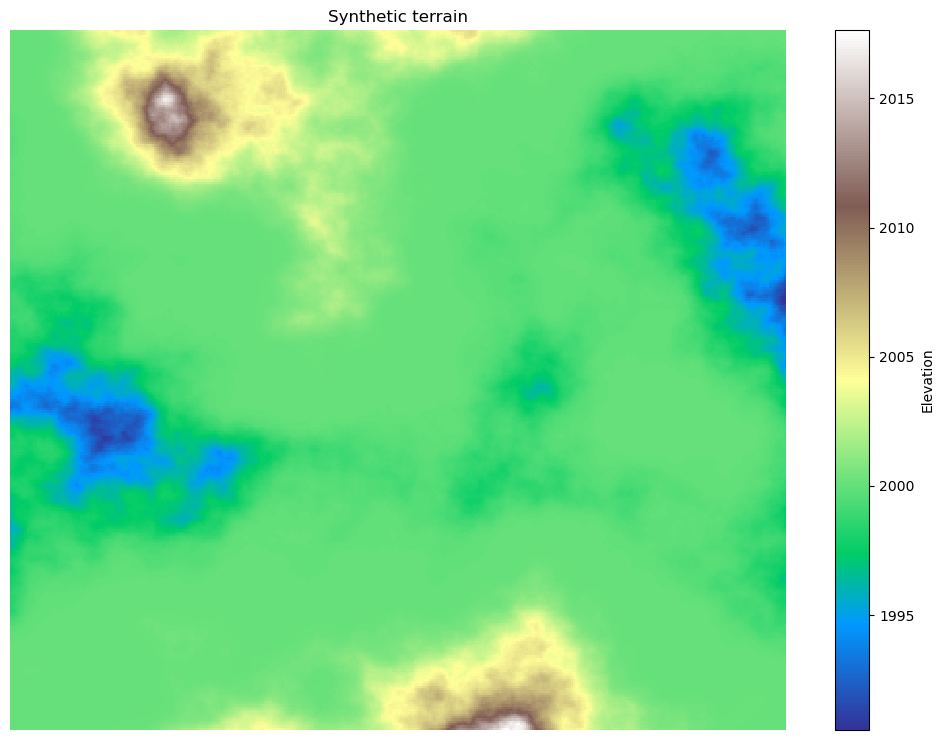

In [2]:
W, H = 400, 300
terrain = generate_terrain(xr.DataArray(np.zeros((H, W))))
hs = hillshade(terrain)

fig, ax = plt.subplots(figsize=(10, 7.5))
terrain.plot.imshow(ax=ax, cmap='terrain', add_colorbar=True,
                    cbar_kwargs={'label': 'Elevation'})
ax.set_title('Synthetic terrain')
ax.set_axis_off()
plt.tight_layout()

## Basic contours

Extract contour lines at specific elevation levels. The function returns a list of `(level, coordinates)` tuples where each coordinates array has shape `(N, 2)` with `(row, col)` positions.

In [3]:
# Pick a few specific levels
vmin, vmax = float(np.nanmin(terrain.values)), float(np.nanmax(terrain.values))
levels = np.linspace(vmin, vmax, 12)[1:-1]  # 10 interior levels

lines = contours(terrain, levels=levels)
print(f'Extracted {len(lines)} contour polylines across {len(levels)} levels')

# Show the first result
level, coords = lines[0]
print(f'First line: level={level:.1f}, {len(coords)} vertices')

Extracted 85 contour polylines across 10 levels
First line: level=1993.0, 145 vertices


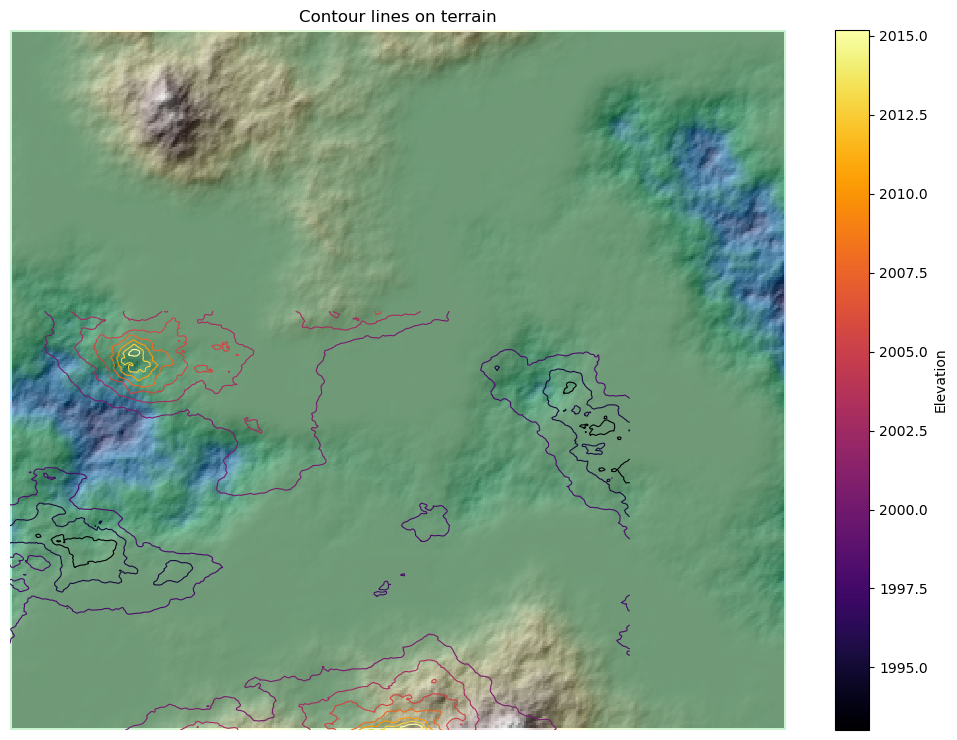

In [4]:
fig, ax = plt.subplots(figsize=(10, 7.5))
hs.plot.imshow(ax=ax, cmap='gray', add_colorbar=False)
terrain.plot.imshow(ax=ax, cmap='terrain', alpha=0.35, add_colorbar=False)

unique_levels = sorted(set(lvl for lvl, _ in lines))
cmap = plt.cm.inferno
norm = plt.Normalize(vmin=min(unique_levels), vmax=max(unique_levels))

for level, coords in lines:
    ax.plot(coords[:, 1], coords[:, 0], color=cmap(norm(level)), linewidth=0.8)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='Elevation')
ax.set_title('Contour lines on terrain')
ax.set_axis_off()
plt.tight_layout()

## Automatic levels

When `levels` is not specified, the function picks `n_levels` evenly spaced values between the raster's min and max. This is convenient for quick exploration.

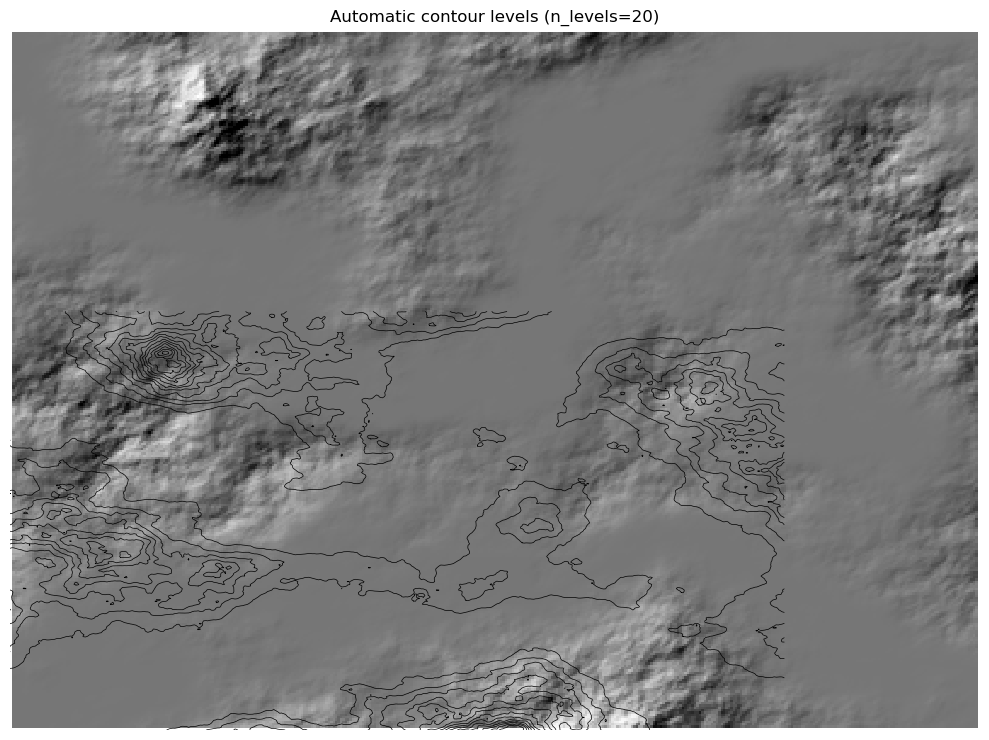

In [5]:
auto_lines = contours(terrain, n_levels=20)

fig, ax = plt.subplots(figsize=(10, 7.5))
hs.plot.imshow(ax=ax, cmap='gray', add_colorbar=False)

for level, coords in auto_lines:
    ax.plot(coords[:, 1], coords[:, 0], 'k-', linewidth=0.5)

ax.set_title('Automatic contour levels (n_levels=20)')
ax.set_axis_off()
plt.tight_layout()

## GeoDataFrame output

Set `return_type='geopandas'` to get a GeoDataFrame with `level` and `geometry` columns. This is useful for spatial analysis or export to GIS formats like GeoJSON or Shapefile.

In [6]:
gdf = contours(terrain, levels=levels, return_type='geopandas')
print(f'GeoDataFrame with {len(gdf)} contour lines')
gdf.head(10)

GeoDataFrame with 85 contour lines


,level,geometry
0,1993.016972,"LINESTRING (42 116.207, 41.164 117, 41.106 118..."
1,1993.016972,"LINESTRING (34.604 134, 35 133.875, 35.403 134..."
2,1993.016972,"LINESTRING (30.303 135, 31 134.344, 32 134.658..."
3,1993.016972,"LINESTRING (18 137.59, 17.137 138, 17 138.253,..."
4,1993.016972,"LINESTRING (399 176.732, 398 176.709, 397 176...."
5,1993.016972,"LINESTRING (388 184.893, 387.88 185, 387.59 18..."
6,1993.016972,"LINESTRING (380 185.284, 379.319 186, 379.793 ..."
7,1993.016972,"LINESTRING (392 207.721, 391.761 208, 391.369 ..."
8,1993.016972,"LINESTRING (374 210.623, 373.737 211, 373.396 ..."
9,1993.016972,"LINESTRING (371 212.789, 370.679 213, 371 213...."


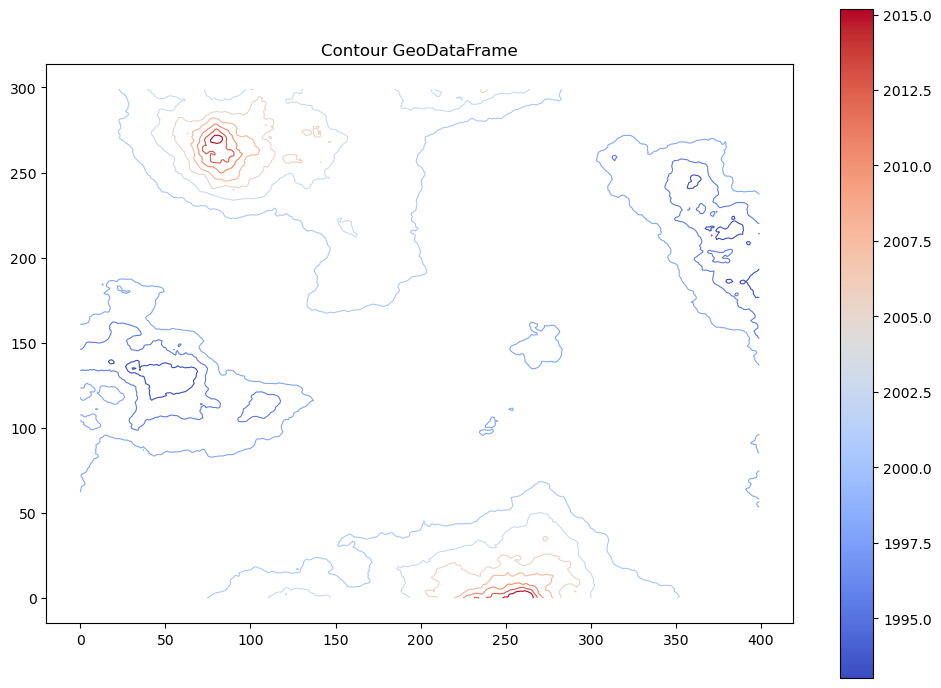

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
gdf.plot(ax=ax, column='level', cmap='coolwarm', linewidth=0.8, legend=True)
ax.set_title('Contour GeoDataFrame')
ax.set_aspect('equal')
plt.tight_layout()

## Topographic overlay

Combine hillshade with contour lines for a classic topographic map look. Every 5th contour is drawn thicker as an index contour.

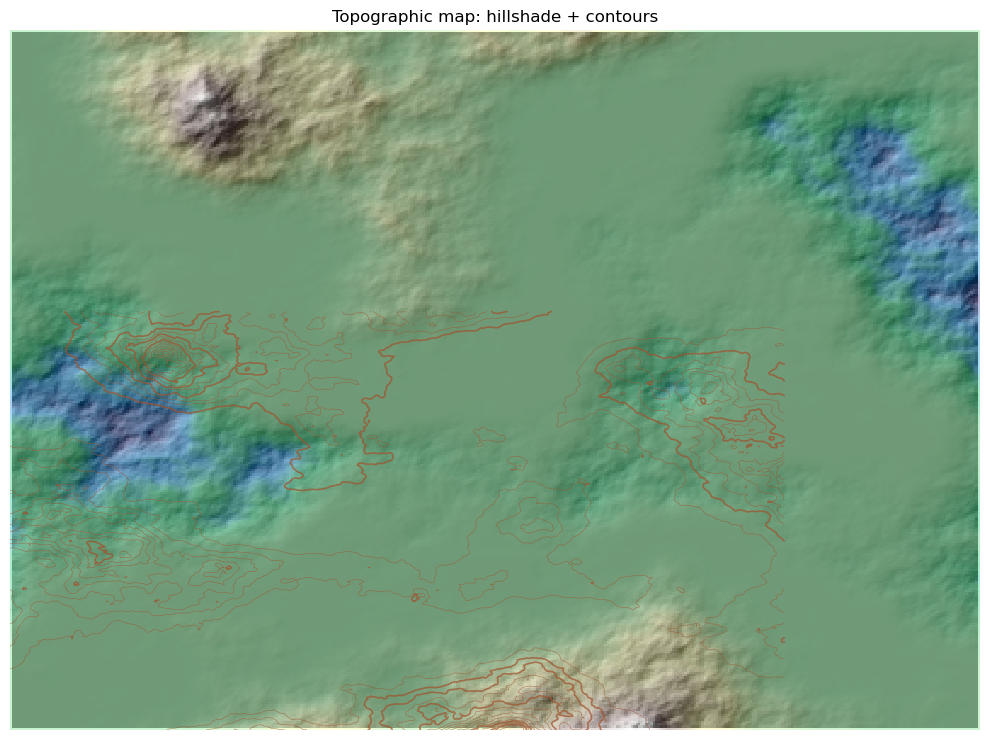

In [8]:
fig, ax = plt.subplots(figsize=(10, 7.5))
hs.plot.imshow(ax=ax, cmap='gray', add_colorbar=False)
terrain.plot.imshow(ax=ax, cmap='terrain', alpha=0.35, add_colorbar=False)

for i, (level, coords) in enumerate(auto_lines):
    lw = 1.2 if i % 5 == 0 else 0.4
    ax.plot(coords[:, 1], coords[:, 0], 'sienna', linewidth=lw, alpha=0.7)

ax.set_title('Topographic map: hillshade + contours')
ax.set_axis_off()
plt.tight_layout()

# Save preview
import pathlib
pathlib.Path('images').mkdir(exist_ok=True)
fig.savefig('images/contour_lines_preview.png', bbox_inches='tight', dpi=120)

### References

- [Marching squares algorithm (Wikipedia)](https://en.wikipedia.org/wiki/Marching_squares)
- [Contour line (Wikipedia)](https://en.wikipedia.org/wiki/Contour_line)
- [xrspatial.contours API docs](https://xarray-spatial.readthedocs.io/en/latest/reference/_autosummary/xrspatial.contours.html)